# electricity_forecast.API.ipynb
Tiny demo showing the helper API. Runs on a small slice of your CSV.

In [3]:
# imports and helper import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from electricity_forecast_utils import (
    load_first_csv_in_data,
    prepare_data_from_df,
    build_lstm_model,
    train_model,
    invert_and_eval,
)

print("Helpers loaded.")

Helpers loaded.


In [4]:
# load the first CSV we find under data/
df = load_first_csv_in_data("data")
print("Columns found:", list(df.columns))
df.head(3)

Loaded: data/AEP_hourly.csv
Columns found: ['Datetime', 'AEP_MW']


,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0


In [6]:
# Prepare the time series windows
TIMESTAMP_COL = "Datetime"
VALUE_COL = "AEP_MW"

X_train, y_train, X_val, y_val, scaler = prepare_data_from_df(
    df,
    timestamp_col=TIMESTAMP_COL,
    value_col=VALUE_COL,
    freq="H",         # hourly data
    window_size=24,   # 24-hour input window
    horizon=1,        # predict next hour
    val_fraction=0.2  # last 20% as validation
)

print("Prepared data shapes:")
print(" X_train:", X_train.shape)
print(" y_train:", y_train.shape)
print(" X_val:  ", X_val.shape)
print(" y_val:  ", y_val.shape)

Prepared data shapes:
 X_train: (97012, 24, 1)
 y_train: (97012,)
 X_val:   (24236, 24, 1)
 y_val:   (24236,)


/Users/mohitsalur/Documents/AtoZ/Projects/src/umd_classes1/class_project/MSML610/Fall2025/Projects/UmdTask124_Keras_Tuner_Electricity_Consumption_Prediction_LSTMs_Hard/electricity_forecast_utils.py:43: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample(freq).mean()


In [7]:
# Build a small LSTM and train briefly
model = build_lstm_model(input_shape=(X_train.shape[1], X_train.shape[2]), units=32, dropout=0.1, lr=1e-3)

hist = train_model(
    model,
    X_train, y_train,
    X_val, y_val,
    epochs=5,      # short run for demo
    batch_size=64,
    patience=2
)

print("Training done. Last epoch (train loss, val loss):", hist.history['loss'][-1], hist.history['val_loss'][-1])

Epoch 1/5
1516/1516 - 5s - 3ms/step - loss: 0.0053 - mae: 0.0525 - val_loss: 9.8578e-04 - val_mae: 0.0245
Epoch 2/5
1516/1516 - 4s - 3ms/step - loss: 0.0013 - mae: 0.0275 - val_loss: 4.1586e-04 - val_mae: 0.0155
Epoch 3/5
1516/1516 - 4s - 3ms/step - loss: 7.5676e-04 - mae: 0.0208 - val_loss: 2.7660e-04 - val_mae: 0.0122
Epoch 4/5
1516/1516 - 4s - 3ms/step - loss: 5.5943e-04 - mae: 0.0176 - val_loss: 2.5672e-04 - val_mae: 0.0124
Epoch 5/5
1516/1516 - 4s - 3ms/step - loss: 4.9498e-04 - mae: 0.0165 - val_loss: 2.7570e-04 - val_mae: 0.0130
Training done. Last epoch (train loss, val loss): 0.0004949844442307949 0.00027569971280172467


758/758 ━━━━━━━━━━━━━━━━━━━━ 1s 808us/step
MAE: 198.085, RMSE: 256.887


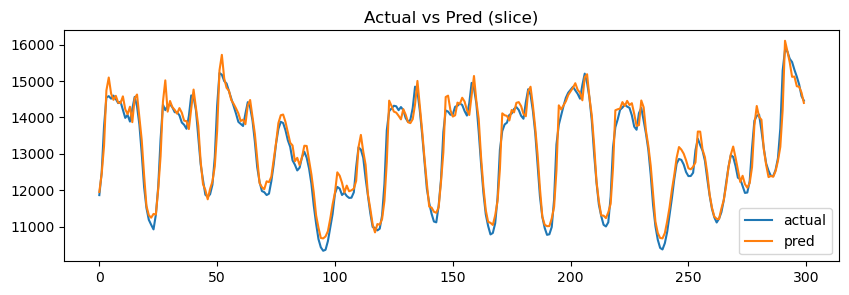

In [8]:
# Predict and compute simple metrics
y_pred_scaled = model.predict(X_val).reshape(-1)
y_true, y_pred, mae, rmse = invert_and_eval(y_val, y_pred_scaled, scaler)

print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}")

# quick plot of a slice (first 300 points)
import matplotlib.pyplot as plt
plt.figure(figsize=(10,3))
plt.plot(y_true[:300], label="actual")
plt.plot(y_pred[:300], label="pred")
plt.legend()
plt.title("Actual vs Pred (slice)")
plt.show()